Transfer learning is a method where we use a pre-trained neural network instead of training a model from scratch. Powerful models like ResNet, AlexNet, InceptionNet, or DenseNet are already trained on very large datasets such as ImageNet, which contains 1000 classes. These networks have already learned important low-level features like edges, lines, textures, and simple shapes in their early layers.

In transfer learning, we take one of these pre-trained models and freeze its layers so their learned weights do not change. Then we remove the final classification layer (which was originally designed to output 1000 classes) and replace it with a new final layer that matches our own task. For example, if we want to classify dogs, cats, cows, and sheep, we would modify the final layer to output only the number of classes we need (for example, 4 or 5). After that, we train only this new final layer on our dataset. Since the earlier layers already know how to extract useful image features, we only need to retrain the last layer to adapt the model to our specific classes. This makes training faster, requires less data, and usually gives very good results.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torch.autograd import Variable
from torchvision import datasets, models, transforms
import os
import numpy as np

# Data augmentation and normalization for training

In our training pipeline, we apply several transforms to prepare the images before feeding them into the neural network.  

The goal is:

1. Perform **data augmentation**
2. Ensure **all images are 224 × 224**
3. Convert images into **PyTorch tensors**
4. Normalize them for stable training

---

## 1️⃣ RandomResizedCrop(224)

This is the first data augmentation step.

### What it does:

- It **randomly crops** a portion of the image.
- The crop size is between **8% (0.08) and 100% (1.0)** of the original image area.
- The aspect ratio is randomly chosen between **3/4 and 4/3**.
- After cropping, the image is resized to **224 × 224** (because our model ResNet expect images of this size) using **bilinear interpolation (default)**.


- It ensures the **final image size is always 224 × 224** for all images

---

## 2️⃣ RandomHorizontalFlip()

This randomly flips the image horizontally.

- It keeps default probability (usually 50%).


## 3️⃣ ToTensor()

PyTorch works with **tensors**, not raw images.

This transform:

- Converts image pixel values from `[0, 255]`
- To floating-point values in `[0, 1]`
- Changes shape from:
  
  `H × W × C  →  C × H × W`

Without this step, PyTorch cannot process the image.

---

## 4️⃣ Normalize(mean, std)

This is one of the most important steps.

We normalize each channel using the formula:

$$
\text{input[channel]} = \frac{\text{input[channel]} - \text{mean[channel]}}{\text{std[channel]}}
$$
### For RGB images:

We have 3 channels:
- R (Red)
- G (Green)
- B (Blue)

So mean and std must be sequences of 3 values.

Example (ImageNet statistics):
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


These represent:
- Mean of R, G, B channels
- Standard deviation of R, G, B channels



##  Where Do Mean and Std Come From?

Ideally:

- You loop through your dataset
- Use `.mean()` and `.std()` in PyTorch
- Calculate statistics for each channel

However:
- Most natural image datasets have values close to ImageNet statistics
- So we often reuse these values

---

##  Why Training and Validation Transforms Differ

Training:
- RandomResizedCrop
- RandomHorizontalFlip
- Adds randomness

Validation:
- Resize
- CenterCrop
- No randomness

We want:
- **Randomness for training**
- **Consistency for evaluation**

---


Final output:
- Tensor
- Shape: `3 × 224 × 224`
- Properly normalized
- Ready for CNN input


In [3]:

# Store training and validation transformations in a dictionary (data_transforms).
# This allows easy access like data_transforms['train'] or data_transforms['val'].


data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Loading the dataset

#  Dataset Folder Structure (How PyTorch Gets Labels)

Before training, images must be arranged in a specific folder structure.

Working directory:

```text
dataset/
│
├── train/
│   ├── ants/
│   │   ├── img1.jpg
│   │   ├── img2.jpg
│   │   └── ...
│   │
│   └── bees/
│       ├── img1.jpg
│       ├── img2.jpg
│       └── ...
│
└── val/
    ├── ants/
    └── bees/
```

---

##  Important Concept

PyTorch (using `ImageFolder`) automatically assigns labels based on **folder names**.

- All images inside `ants/` → label = "ants"
- All images inside `bees/` → label = "bees"

So we do NOT manually assign labels.

The folder name itself becomes the class label.



#  Creating Image Datasets Using ImageFolder

Now we load images from our dataset folders and create dataset objects for training and validation.

We use:

    torchvision.datasets.ImageFolder

---

## 🔹 What ImageFolder Does

`ImageFolder`:

- Reads images from a directory
- Automatically assigns labels based on folder names
- Applies transformations if provided

So we don’t manually label images — the folder name becomes the label.

---

##  Goal

We want to create a dictionary that contains:

- Training dataset
- Validation dataset



##  Code Logic (Conceptually)

We loop over:

    for x in ['train', 'val']

During the loop:

- First iteration → x = "train"
- Second iteration → x = "val"

For each value of `x`, we create a dataset.

---

##  Path Construction

We use:

    os.path.join(data_dir, x)

This simply joins two strings:

- `data_dir` → main dataset folder
- `x` → either "train" or "val"

So it becomes:

- dataset/train
- dataset/val


---

##  Applying Transforms

So when:

- x = "train" → apply data_transforms['train']
- x = "val" → apply data_transforms['val']

Each dataset gets its corresponding transforms.

---



So now:

- image_datasets['train'] contains training images
- image_datasets['val'] contains validation images



In [4]:

data_dir = 'hymenoptera_data'
#Create a dictionary that contains the information of the images in both the training and validation set
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),data_transforms[x]) for x in ['train', 'val']}

#Create a dictionary that contians the data loader
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], 
                                              batch_size=4,
                                              shuffle=True) for x in ['train', 'val']}

#Create a dictionary that contains the size of each dataset (training and validation)
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
#Get the class names
class_names = image_datasets['train'].classes   #doesn't matter "train" or "val" because both classes have exact same images and same labels
#Print out the results 
print("Class Names: {}".format(class_names))
print("There are {} batches in the training set".format(len(dataloaders['train'])))
print("There are {} batches in the test set".format(len(dataloaders['val'])))
print("There are {} training images".format(dataset_sizes['train']))
print("There are {} testing images".format(dataset_sizes['val']))



Class Names: ['ants', 'bees']
There are 61 batches in the training set
There are 39 batches in the test set
There are 244 training images
There are 153 testing images


# Modifying the Network

In [5]:
#Loading the pretrained ResNet
model_conv = torchvision.models.resnet18(pretrained=True)
# by setting pretrained=True, we are taking pretrained weights from the model

/usr/local/python/3.12.1/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
model_conv.parameters

<bound method Module.parameters of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


# Freezing Pretrained Layers (Transfer Learning)

We are using a pretrained Residual Network (ResNet) as `model_conv`.

In transfer learning, we **do NOT train the entire network again**.  
Instead:

- We keep all pretrained layers fixed.
- We only train the **last layer** (the classifier).

---

##  Why Freeze Layers?

The pretrained network has already learned useful features like:

- Edges
- Shapes
- Textures
- High-level visual patterns

We don’t want to destroy this knowledge.

So we freeze the earlier layers and only retrain the final layer for our specific task (e.g., ants vs bees).

---

##  What Are Model Parameters?

Every neural network layer has parameters (see the ouput from previous cell):

- Weights
- Biases
- Convolution filters

When we define an optimizer like:

```python
optimizer = optim.SGD(model.parameters(), lr=0.001)
```

We pass these parameters to be updated during training.

If we freeze them, they will NOT be updated.

---

##  How Freezing Works in PyTorch

Each parameter has an attribute:

```python
requires_grad
```

- `True` → PyTorch computes gradients and updates the parameter.
- `False` → PyTorch does NOT compute gradients, so no backpropagation happens.

To freeze all layers:

```python
for param in model_conv.parameters():
    param.requires_grad = False
```

This means:

- No gradient tracking
- No weight updates
- No backpropagation through these layers

---



So during training:

- Forward pass still happens.
- But backward pass does NOT update those weights.



In [7]:

#Freeze all layers in the network  
for param in model_conv.parameters():  
    param.requires_grad = False



# Replacing the Final Fully Connected Layer

The pretrained ResNet model was trained on ImageNet (1000 classes).

Since our dataset has only 2 classes (ants and bees),
we must replace the final ``fully connected layer``.



## Step 1: Get Number of Input Features

The original final layer looks like:

    Linear(in_features=512, out_features=1000)

We extract the number of input features:

    num_ftrs = model_conv.fc.in_features

This gives us 512.



## Step 2: Replace the Final Layer

We build a new Linear layer:

    model_conv.fc = nn.Linear(num_ftrs, 2)

- 512 inputs (same as before)
- 2 outputs (ants and bees)



Now:

- All earlier layers remain frozen.
- Only the new final layer is trainable.
- The model is ready for transfer learning.

In [8]:
model_conv.fc

Linear(in_features=512, out_features=1000, bias=True)

In [9]:


#Get the number of inputs of the last layer (or number of neurons in the layer preceeding the last layer)
num_ftrs = model_conv.fc.in_features
#Reconstruct the last layer (output layer) to have only two classes 
model_conv.fc = nn.Linear(num_ftrs, 2)



In [10]:


if torch.cuda.is_available():
    model_conv = model_conv.cuda()



# Understanding the data

`iteration` is a counter.

After the first batch, iteration becomes 1, so the loop stops next time.
Purpose: only show one batch output, not the whole dataset.

`correct` is used to store the number of correct predictions in every batch. So here, the number of correct predictions from 1st batch

## Explanations of the output of the followin cell
Input Shape: `torch.Size([4, 3, 224, 224])` => batch_size, channels_number, height, width. The height and widht are expected to be 224 because if you remeber in data augmentation we resized the image to 224*224.


`Labels Shape: torch.Size([4])` ,

`Labels are: tensor([0, 1, 0, 0])`

The labels tensor is one-dimensional with size 4 because we have 4 images in the batch.

Example:
`tensor([0, 1, 0, 0])`

Since we only have two classes (ants and bees), the labels are either 0 or 1.



## Output Tensor

After the forward pass:

```python
output = model_conv(inputs)
```

Output shape: `torch.Size([4, 2])`

- 4 = number of images in the batch  
- 2 = number of classes  

Each row represents one image, and each column is the score for a class.
The higher score determines the predicted class.






## Predicted Classes

```python
_, predicted = torch.max(output, 1)
```

`torch.max(output, 1)` returns:
- the maximum scores  
- the indices of those scores  

We ignore the scores (`_`) and keep the indices as predictions.

Since output shape is `[4, 2]`, taking max across rows gives:

```
tensor([1, 0, 1, 0])
```

Shape: `torch.Size([4])`  
One predicted class (0 or 1) for each image.



In [11]:


#Understand what's happening
iteration = 0
correct = 0
for inputs,labels in dataloaders['train']:
    if iteration==1:
        break

    # Variable() was used in older PyTorch versions to enable automatic gradient tracking.
    # In modern PyTorch, tensors already support autograd, so Variable() is no longer necessary.
    inputs = Variable(inputs)
    labels = Variable(labels)

    if torch.cuda.is_available():
        inputs = inputs.cuda()
        labels = labels.cuda()


    print("For one iteration, this is what happens:")
    print("Input Shape:",inputs.shape)
    print("Labels Shape:",labels.shape)
    print("Labels are: {}".format(labels))  # of the 1st batch

    output = model_conv(inputs)     # Forward pass through our conv model  
                                    # and save the results as outpur

    
    print("Outputs Shape",output.shape)
    print("Output Tensor:", output)
    

    _, predicted = torch.max(output, 1)     # takes the maximum across each row
    print("Predicted:", predicted)
    print("Predicted Shape",predicted.shape)

    correct += (predicted == labels).sum()   # calculates how many correct predictions we have
    print("Correct Predictions:",correct)
    
    iteration += 1



For one iteration, this is what happens:
Input Shape: torch.Size([4, 3, 224, 224])
Labels Shape: torch.Size([4])
Labels are: tensor([0, 0, 1, 1])
Outputs Shape torch.Size([4, 2])
Output Tensor: tensor([[1.7436, 1.1723],
        [1.0866, 1.7010],
        [0.6569, 1.2125],
        [0.7717, 0.9154]], grad_fn=<AddmmBackward0>)
Predicted: tensor([0, 1, 1, 1])
Predicted Shape torch.Size([4])
Correct Predictions: tensor(3)


### Define the loss function

For the loss function, we can use Binary Cross entropy as well as there are 2 classes only.

###  Optimizer

```python
optimizer = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)
```

We use **Stochastic Gradient Descent (SGD)**.



We only pass:

```python
model_conv.fc.parameters()
```

This means:

- We are optimizing **only the final fully connected layer**
- All other layers are frozen (transfer learning)

Parameters:

- `lr=0.001` → learning rate (step size for updates)
- `momentum=0.9` → helps smooth and accelerate training


##  Learning Rate Scheduler

```python
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
```

Every 7 epochs, the learning rate is multiplied by 0.1, that means automatically reduces the learning rate during training

Example:
0.001 → 0.0001 → 0.00001

Reducing the learning rate over time makes training more stable and helps the model converge better otherwise the model may jump between high and low loss/accuracy.

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)
#Try experimenting with: optim.Adam(model_conv.fc.parameters(), lr=0.001)


#Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Finetuning the Network

## Epoch Loop and Learning Rate Scheduler

We train the model for **25 epochs**, meaning the dataset is passed through the network 25 times. Since we are using transfer learning and only training the final layer, 25 epochs is usually sufficient.

`exp_lr_scheduler.step()` updates the learning rate once per 7 epoch. With `StepLR(step_size=7, gamma=0.1)`, the learning rate is reduced by a factor of 0.1 every 7 epochs. The scheduler should be placed inside the epoch loop, not inside the batch loop.


## Training Steps Inside Each Epoch

At the start of each epoch, `correct` is reset to 0.  
Then we iterate through the training dataloader to load batches of images and labels. The data is wrapped in `Variable` and moved to the GPU if available.

For each batch:
- Reset gradients (`optimizer.zero_grad()`)
- Run the forward pass to get outputs
- Compute the loss
- Backpropagate the loss (`loss.backward()`)
- Update model weights (`optimizer.step()`)
- Get predicted classes and count correct predictions



In [13]:
num_epochs = 25
for epoch in range (num_epochs):
    exp_lr_scheduler.step()

    #Reset the correct to 0 after passing through all the dataset that means, after every epoch 
    correct = 0
    for images,labels in dataloaders['train']:
        images = Variable(images)
        labels = Variable(labels)
        if torch.cuda.is_available():
            images = images.cuda()
            labels = labels.cuda()
            
        optimizer.zero_grad()
        outputs = model_conv(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()  
        _, predicted = torch.max(outputs, 1) 
        correct += (predicted == labels).sum()
        
    train_acc = 100 * correct / dataset_sizes['train']    
    print ('Epoch [{}/{}], Loss: {:.4f}, Train Accuracy: {}%'
            .format(epoch+1, num_epochs, loss.item(), train_acc))

/tmp/ipykernel_2039/3489303253.py:3: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  exp_lr_scheduler.step()


Epoch [1/25], Loss: 0.5634, Train Accuracy: 58.196720123291016%
Epoch [2/25], Loss: 0.2872, Train Accuracy: 76.63934326171875%
Epoch [3/25], Loss: 1.4445, Train Accuracy: 75.40983581542969%
Epoch [4/25], Loss: 1.0686, Train Accuracy: 75.0%
Epoch [5/25], Loss: 0.1577, Train Accuracy: 84.01639556884766%
Epoch [6/25], Loss: 0.0022, Train Accuracy: 81.55738067626953%
Epoch [7/25], Loss: 0.2070, Train Accuracy: 82.3770523071289%
Epoch [8/25], Loss: 0.0109, Train Accuracy: 89.3442611694336%
Epoch [9/25], Loss: 0.0051, Train Accuracy: 83.60655975341797%
Epoch [10/25], Loss: 0.1604, Train Accuracy: 81.14753723144531%
Epoch [11/25], Loss: 0.4591, Train Accuracy: 82.7868881225586%
Epoch [12/25], Loss: 1.1944, Train Accuracy: 81.96721649169922%
Epoch [13/25], Loss: 0.4591, Train Accuracy: 84.01639556884766%
Epoch [14/25], Loss: 1.6729, Train Accuracy: 86.88524627685547%
Epoch [15/25], Loss: 0.4502, Train Accuracy: 88.9344253540039%
Epoch [16/25], Loss: 0.3478, Train Accuracy: 84.83606719970703%
E

# Testing and visualizing the rsults



To test the trained model, we first switch it to **evaluation mode**:

```python
model_conv.eval()
```

This tells PyTorch the model is being used for evaluation, not training.

Next, we use:

```python
with torch.no_grad():
```

This disables gradient tracking, which saves memory and computation since we are not updating weights during testing.

We then loop through the **validation dataloader**, load the images and labels, wrap them as variables, and move them to the GPU if one is available.


And then the images are forward propagated through the model to obtain predictions.  
For each batch, we:

- Compute the model outputs
- Get the predicted class using the maximum score
- Increase the total number of samples
- Count how many predictions match the true labels

Finally, the **test accuracy** is calculated and the result is printed.

In [14]:
# Test the model
model_conv.eval()  
with torch.no_grad():
    correct = 0
    total = 0
    for (images, labels) in dataloaders['val']:
        images = Variable(images)
        labels = Variable(labels)
        if torch.cuda.is_available():
            images = images.cuda()
            labels = labels.cuda()

        outputs = model_conv(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Test Accuracy: {:.3f} %'.format(100 * correct / total))



Test Accuracy: 92.810 %


As we can see, the testing accuracy is even better than the training accuracy.

## Preparing Image Tensor for Visualization

To display the image using matplotlib, the tensor must be moved from GPU to CPU:

```python
input_img = images.cpu().data[i]
```

Then it is converted from a **PyTorch tensor** to a **NumPy array**:

```python
inp = input_img.numpy()
```

PyTorch stores images in **(C, H, W)** format (channels, height, width),  
but matplotlib expects **(H, W, C)** format.

So we reorder the dimensions using:

```python
inp = inp.transpose((1, 2, 0))
```

This rearranges the tensor so the image can be displayed correctly. Without this step, the image would appear distorted during visualization.



## Un-normalizing the Image for Visualization

Earlier, the images were **normalized** during preprocessing.

Before displaying the image, we must **undo this normalization** (un-normalize) so the colors look correct.

This is done using the same mean and standard deviation values:

```python
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
```

This restores the image back to its original pixel scale so it can be visualized properly.


`np.clip(inp, 0, 1)` ensures all pixel values stay within the valid range `[0,1]` for image display.  
After un-normalization some values may go below 0 or above 1, which can cause incorrect colors when visualizing the image.
```python
[-0.12, 0.45, 1.08] => [0.0, 0.45, 1.0]
```

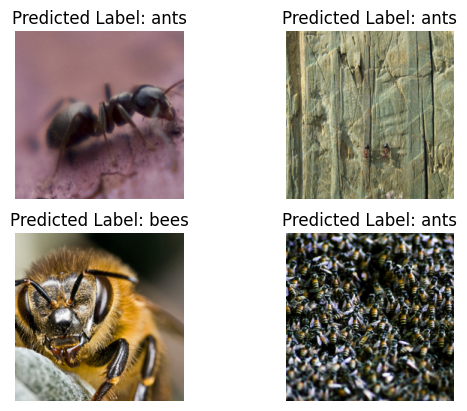

In [16]:
#Visualize some predictions 
import matplotlib.pyplot as plt
fig = plt.figure()  # plotting an empty figure
shown_batch = 0
index = 0
with torch.no_grad():   # as we are not back propagating anything here as well.
    for (images, labels) in dataloaders['val']:
        if shown_batch == 1:    # as we only want to visualize only 1 batch
            break
        shown_batch += 1
        images = Variable(images)
        labels = Variable(labels)
        if torch.cuda.is_available():
            images = images.cuda()
            labels = labels.cuda()

        outputs = model_conv(images)                            #The output is of shape (4,2)
        _, preds = torch.max(outputs, 1)                        #The pred is of shape (4) --> [ 0,  0,  0,  1]
        

        # now we'll show the images
        for i in range(4):
            index += 1  # used to subplot in a single figure
            ax = plt.subplot(2,2,index)     # 2 rows, 2 columns => total 4 images 
            ax.axis('off')
            ax.set_title('Predicted Label: {}'.format(class_names[preds[i]]))
            input_img = images.cpu().data[i]                    #Get the tensor of the image, and put it to cpu  
            inp = input_img.numpy().transpose((1, 2, 0))        #If we have a tensor of shape (2,3,4) --> it becomes (3,4,2)
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            inp = std * inp + mean
            inp = np.clip(inp, 0, 1)
            plt.imshow(inp)


## Transfer Learning with ResNet

In transfer learning, we use a pretrained ResNet and replace its final fully connected layer with a new layer suited for our task. In this example, the last layer was modified to classify only **two classes (ants and bees)** instead of the original 1000 ImageNet classes.

The same approach can be extended to any number of categories by adjusting the output layer. The key idea is understanding how to reuse a pretrained network and adapt its final layer for a new classification task.

